# B"H
# Final Project in Medical Imaging
## VGG Implementation

---
### Supervisor: Dr. Eyal Ben-Issac
### Students: Lior Cohen & Tomer Peretz
### Date: 20.07.2025

# Loading

In [42]:
import os
import cv2
import random
import shutil
import joblib
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns
import tensorflow as tf
from sklearn.svm import SVC
from google.colab import auth
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, models
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import VGG19
from oauth2client.client import GoogleCredentials
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
warnings.filterwarnings("ignore")

## Fetching

> Loading the images from Google Drive

*   We started with a publicly accessible folder in Google Drive containing subfolders of images.
*   Using the pydrive library, we authenticated and accessed the folder and its contents programmatically.







In [2]:
# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


folder_id = '19sZid9MtP40UcVuFlmFAfuFx7P49MxkK'
file_list = drive.ListFile({'q': f"'{folder_id}' in parents and trashed=false"}).GetList()

for file in file_list:
    print(f"Title: {file['title']}, ID: {file['id']}")

Title: 01, ID: 1ymtm84uqm8nLAH_YSxMmjjRznO2LVUKs
Title: 03, ID: 1t2yWUtnGU5Z7zN6xZa6rFoX89fgc1oC1
Title: 02, ID: 1n6vq7zH7CiyTbcpl4YCkR7th5-4_xs1e


> Deleting folders in Google Drive's local temp folder

In [3]:
try:
  shutil.rmtree("/content/sample_data")
except FileNotFoundError:
  print("The directory alrealy removed")

> Loading the images and saves them in local Drive folder

**It takes about 5 minutes to load**

In [4]:
base_dir = '/content/dataset'
os.makedirs(base_dir, exist_ok=True)

# Download files and maintain folder structure
for file in file_list:
    if file['mimeType'] == 'application/vnd.google-apps.folder':  # If it's a folder
        subfolder_name = file['title']
        subfolder_id = file['id']
        subfolder_path = os.path.join(base_dir, subfolder_name)
        os.makedirs(subfolder_path, exist_ok=True)
        subfolder_files = drive.ListFile({'q': f"'{subfolder_id}' in parents and trashed=false"}).GetList()

        # Download images into the subfolder
        for subfile in subfolder_files:
            if subfile['mimeType'].startswith('image/'):  # If it's an image
                subfile.GetContentFile(os.path.join(subfolder_path, subfile['title']))
                print(f"Downloaded {subfile['title']} to {subfolder_path}")
    elif file['mimeType'].startswith('image/'):  # If it's an image directly in the main folder
        file.GetContentFile(os.path.join(base_dir, file['title']))
        print(f"Downloaded {file['title']} to {base_dir}")

Downloaded 084.jpeg to /content/dataset/01
Downloaded 052.jpeg to /content/dataset/01
Downloaded 053.jpeg to /content/dataset/01
Downloaded 075.jpeg to /content/dataset/01
Downloaded 081.jpeg to /content/dataset/01
Downloaded 074.jpeg to /content/dataset/01
Downloaded 082.jpeg to /content/dataset/01
Downloaded 064.jpeg to /content/dataset/01
Downloaded 061.jpeg to /content/dataset/01
Downloaded 09.jpeg to /content/dataset/01
Downloaded 078.jpeg to /content/dataset/01
Downloaded 08.jpeg to /content/dataset/01
Downloaded 073.jpeg to /content/dataset/01
Downloaded 076.jpeg to /content/dataset/01
Downloaded 066.jpeg to /content/dataset/01
Downloaded 055.jpeg to /content/dataset/01
Downloaded 06.jpeg to /content/dataset/01
Downloaded 056.jpeg to /content/dataset/01
Downloaded 057.jpeg to /content/dataset/01
Downloaded 094.jpeg to /content/dataset/01
Downloaded 077.jpeg to /content/dataset/01
Downloaded 068.jpeg to /content/dataset/01
Downloaded 051.jpeg to /content/dataset/01
Downloaded 065

## Organizing

> Organize the images


*   We created a local dictionary to store the file paths, where each key represented a subfolder, and the value was a list of file paths for that subfolder.
*   This allowed us to maintain the folder structure and easily access files from each subfolder.






In [5]:
file_paths_dict = {}

for root, dirs, files in os.walk(base_dir):
    if root == base_dir:  # Skip the base directory itself
        continue

    subfolder_name = os.path.basename(root)
    file_paths_dict[subfolder_name] = []

    for f in files:
        file_path = os.path.join(root, f)
        file_paths_dict[subfolder_name].append(file_path)

for subfolder, file_paths in file_paths_dict.items():
    print(f"Subfolder named: {subfolder}, Number of Files: {len(file_paths)}")

Subfolder named: 01, Number of Files: 70
Subfolder named: 03, Number of Files: 111
Subfolder named: 02, Number of Files: 70


> The subfolders should contain:


*   70 photos in folder 01
*   70 photos in folder 02
*  111 photos in folder 03









### Validating Paths

In [6]:
file_paths_dict

{'01': ['/content/dataset/01/031.jpeg',
  '/content/dataset/01/027.jpeg',
  '/content/dataset/01/04.jpeg',
  '/content/dataset/01/048.jpeg',
  '/content/dataset/01/025.jpeg',
  '/content/dataset/01/056.jpeg',
  '/content/dataset/01/082.jpeg',
  '/content/dataset/01/021.jpeg',
  '/content/dataset/01/094.jpeg',
  '/content/dataset/01/01.jpeg',
  '/content/dataset/01/054.jpeg',
  '/content/dataset/01/064.jpeg',
  '/content/dataset/01/067.jpeg',
  '/content/dataset/01/06.jpeg',
  '/content/dataset/01/081.jpeg',
  '/content/dataset/01/044.jpeg',
  '/content/dataset/01/07.jpeg',
  '/content/dataset/01/020.jpeg',
  '/content/dataset/01/013.jpeg',
  '/content/dataset/01/018.jpeg',
  '/content/dataset/01/095.jpeg',
  '/content/dataset/01/068.jpeg',
  '/content/dataset/01/012.jpeg',
  '/content/dataset/01/066.jpeg',
  '/content/dataset/01/037.jpeg',
  '/content/dataset/01/011.jpeg',
  '/content/dataset/01/047.jpeg',
  '/content/dataset/01/073.jpeg',
  '/content/dataset/01/055.jpeg',
  '/content/

# Splitting

> Split the images into Train and Test Sets


*   We split the data such that 25% of the files from each subfolder were randomly selected for the test set, and the remaining 75% were assigned to the train set.
*   This was done using the random.sample function to ensure randomness in the selection.






In [7]:
train_files = {}
test_files = {}

for folder, file_paths in file_paths_dict.items():
    num_test = int(len(file_paths) * 0.25)
    test_files[folder] = random.sample(file_paths, num_test)
    train_files[folder] = [file for file in file_paths if file not in test_files[folder]]

for folder in file_paths_dict.keys():
    print(f"Folder: {folder}")
    print(f"Train Files: {len(train_files[folder])}")
    print(f"Test Files: {len(test_files[folder])}")
    print()

Folder: 01
Train Files: 53
Test Files: 17

Folder: 03
Train Files: 84
Test Files: 27

Folder: 02
Train Files: 53
Test Files: 17



> Unite the Test Files into a Single List


*   Instead of keeping the test files in separate subfolders, we combined all the test file paths into a single list (united_test_files).
*   This made it easier to work with the test data as a unified dataset.

In [8]:
united_test_files = []

for files in test_files.values():
    united_test_files.extend(files)
random.shuffle(united_test_files)

print("United Test Files:", united_test_files)
print("Number of Test Files:", len(united_test_files))

United Test Files: ['/content/dataset/03/COVID-00012.jpg', '/content/dataset/03/082.jpg', '/content/dataset/01/013.jpeg', '/content/dataset/03/COVID-00005.jpg', '/content/dataset/03/COVID-00035.jpg', '/content/dataset/01/036.jpeg', '/content/dataset/03/015.jpg', '/content/dataset/03/03.jpeg', '/content/dataset/03/COVID-00010.jpg', '/content/dataset/01/044.jpeg', '/content/dataset/03/079.jpeg', '/content/dataset/02/082.jpeg', '/content/dataset/03/COVID-00033.jpg', '/content/dataset/02/07.jpeg', '/content/dataset/02/085.jpeg', '/content/dataset/01/056.jpeg', '/content/dataset/03/047.jpeg', '/content/dataset/02/019.jpeg', '/content/dataset/03/074.jpg', '/content/dataset/02/097.jpeg', '/content/dataset/01/054.jpeg', '/content/dataset/03/091.jpg', '/content/dataset/01/034.jpeg', '/content/dataset/03/085.jpeg', '/content/dataset/02/081.jpeg', '/content/dataset/02/064.jpeg', '/content/dataset/03/060.jpeg', '/content/dataset/01/078.jpeg', '/content/dataset/02/072.jpeg', '/content/dataset/02/05

# Converting

> Convert the paths to test images

In [9]:
test_images = [(Image.open(file_path), os.path.basename(os.path.dirname(file_path))) for file_path in united_test_files]
print(f"Number of test images loaded: {len(test_images)}")

Number of test images loaded: 61


In [10]:
assert len(test_images) == len(united_test_files), f"ERROR: Test lists are not equal!"

> Convert the paths to train images

In [11]:
train_images = {}

for folder, file_paths in train_files.items():
    train_images[folder] = [Image.open(file_path) for file_path in file_paths]

for folder, images in train_images.items():
    print(f"Folder: {folder}, Number of Train Images: {len(images)}")

Folder: 01, Number of Train Images: 53
Folder: 03, Number of Train Images: 84
Folder: 02, Number of Train Images: 53


In [12]:
assert len(train_files['01']) == len(train_images['01']), f"ERROR: Train lists No.1 are not equal!"
assert len(train_files['02']) == len(train_images['02']), f"ERROR: Train lists No.2 are not equal!"
assert len(train_files['03']) == len(train_images['03']), f"ERROR: Train lists No.3 are not equal!"

### Validating Test

> In the test list, there are tuples of image and folder

In [13]:
test_images

[(<PIL.JpegImagePlugin.JpegImageFile image mode=L size=556x557>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1165x1163>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1558x1218>, '01'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=3604x2953>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=895x734>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1528x968>, '01'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2972x2840>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=4200x3408>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=1969x1952>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1568x1184>, '01'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1645x1272>, '03'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2446x2224>, '02'),
 (<PIL.JpegImagePlugin.JpegImageFile image mode=L size=972x733>, '03'),
 (<PIL.JpegImagePlugin.JpegIm

In [14]:
for image, folder in test_images:
    print(f"Image: {os.path.basename(image.filename):<15} Folder: {folder}")

Image: COVID-00012.jpg Folder: 03
Image: 082.jpg         Folder: 03
Image: 013.jpeg        Folder: 01
Image: COVID-00005.jpg Folder: 03
Image: COVID-00035.jpg Folder: 03
Image: 036.jpeg        Folder: 01
Image: 015.jpg         Folder: 03
Image: 03.jpeg         Folder: 03
Image: COVID-00010.jpg Folder: 03
Image: 044.jpeg        Folder: 01
Image: 079.jpeg        Folder: 03
Image: 082.jpeg        Folder: 02
Image: COVID-00033.jpg Folder: 03
Image: 07.jpeg         Folder: 02
Image: 085.jpeg        Folder: 02
Image: 056.jpeg        Folder: 01
Image: 047.jpeg        Folder: 03
Image: 019.jpeg        Folder: 02
Image: 074.jpg         Folder: 03
Image: 097.jpeg        Folder: 02
Image: 054.jpeg        Folder: 01
Image: 091.jpg         Folder: 03
Image: 034.jpeg        Folder: 01
Image: 085.jpeg        Folder: 03
Image: 081.jpeg        Folder: 02
Image: 064.jpeg        Folder: 02
Image: 060.jpeg        Folder: 03
Image: 078.jpeg        Folder: 01
Image: 072.jpeg        Folder: 02
Image: 056.jpe

In [15]:
test_images[0]

(<PIL.JpegImagePlugin.JpegImageFile image mode=L size=556x557>, '03')

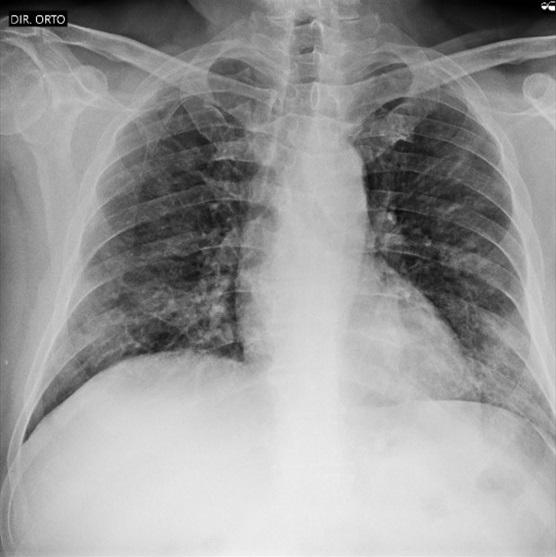

In [16]:
test_images[0][0]

### Validating Train

> In the train dict, the folder is the key, and the list of the images is the value

In [17]:
train_images

{'01': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1488x1136>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1592x1144>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1400x1048>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1192x920>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1352x1064>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1000>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1504x1032>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1268x816>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1582x1333>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1512x991>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1168x840>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1064x840>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1712x1392>,
  <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1456x1080>,
  <PIL.JpegImagePlugin.JpegImageF

In [18]:
for folder, image in train_images.items():
    print(f"Folder: {folder} Images list: {image}")

Folder: 01 Images list: [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1488x1136 at 0x7ADABEB2F5D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1592x1144 at 0x7ADABEB2F450>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1400x1048 at 0x7ADABEF44990>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1192x920 at 0x7ADABEBA3150>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1352x1064 at 0x7ADABEBA05D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1000 at 0x7ADABEBA3410>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1504x1032 at 0x7ADABEBA0A50>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1268x816 at 0x7ADABEBA1ED0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1582x1333 at 0x7ADABEBA2290>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1512x991 at 0x7ADABEBA0B10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1168x840 at 0x7ADABEB41BD0>, <PIL.JpegImagePlugin.JpegImageFile image mod

In [19]:
train_images['01']

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1488x1136>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1592x1144>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1400x1048>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1192x920>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1352x1064>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1000>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1504x1032>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1268x816>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1582x1333>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1512x991>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1168x840>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1064x840>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1712x1392>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1456x1080>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB si

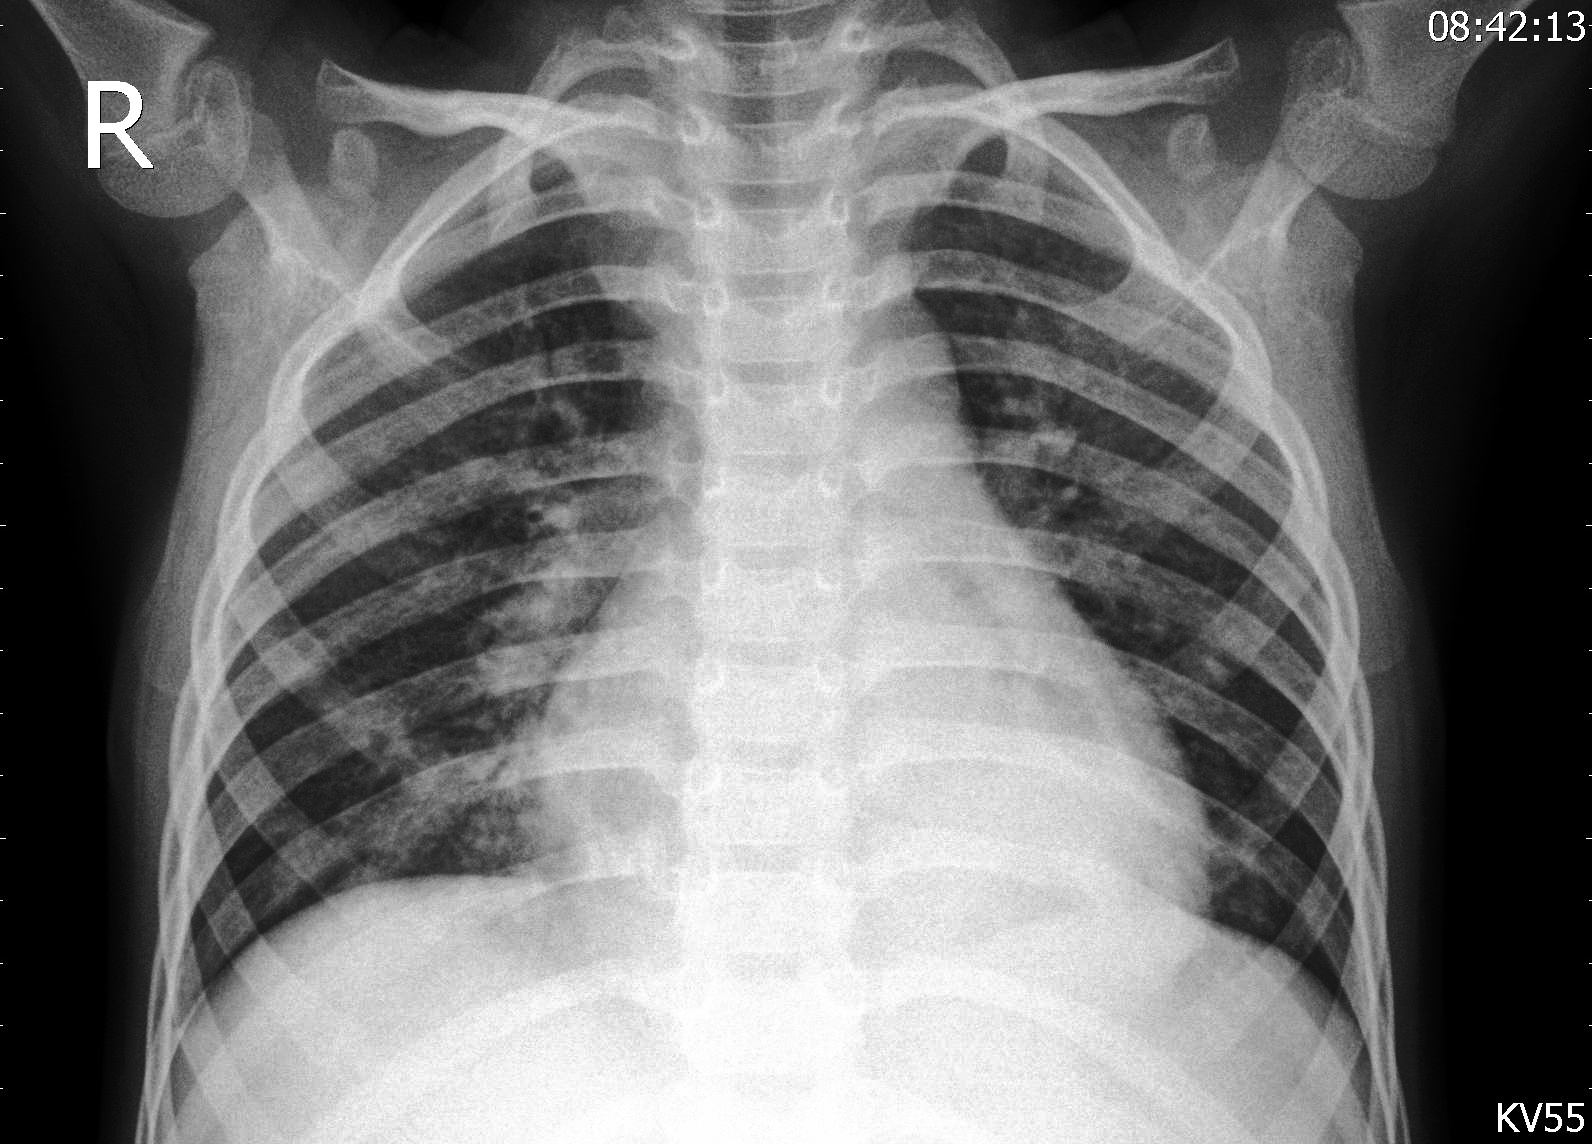

In [20]:
train_images['01'][1]

### Validating Shape

> The shapes of the images are different, so we have to process the images to uniform shape

In [21]:
for folder, images in train_images.items():
    for image in images:
        print(f"Folder: {folder}, Image Shape: {np.array(image).shape}")
print("-"*40)
for image, folder in test_images:
    print(f"Folder: {folder}, Image Shape: {np.array(image).shape}")

Folder: 01, Image Shape: (1136, 1488, 3)
Folder: 01, Image Shape: (1144, 1592, 3)
Folder: 01, Image Shape: (1048, 1400, 3)
Folder: 01, Image Shape: (920, 1192, 3)
Folder: 01, Image Shape: (1064, 1352, 3)
Folder: 01, Image Shape: (1000, 1280, 3)
Folder: 01, Image Shape: (1032, 1504, 3)
Folder: 01, Image Shape: (816, 1268, 3)
Folder: 01, Image Shape: (1333, 1582, 3)
Folder: 01, Image Shape: (991, 1512, 3)
Folder: 01, Image Shape: (840, 1168, 3)
Folder: 01, Image Shape: (840, 1064, 3)
Folder: 01, Image Shape: (1392, 1712, 3)
Folder: 01, Image Shape: (1080, 1456, 3)
Folder: 01, Image Shape: (925, 1190, 3)
Folder: 01, Image Shape: (936, 1216, 3)
Folder: 01, Image Shape: (1000, 1592, 3)
Folder: 01, Image Shape: (1208, 1320, 3)
Folder: 01, Image Shape: (1118, 1365, 3)
Folder: 01, Image Shape: (872, 1544, 3)
Folder: 01, Image Shape: (840, 1056, 3)
Folder: 01, Image Shape: (888, 1512, 3)
Folder: 01, Image Shape: (920, 1288, 3)
Folder: 01, Image Shape: (992, 1600, 3)
Folder: 01, Image Shape: (87

# Modeling

## Normalization

> Normalize the image to size of 224x224.


* This is done by resizing the dimensions of each image

In [47]:
IMG_SIZE = (224, 224)


def standardize_image(image):
    if image.mode != 'RGB':
        image = image.convert('RGB')
    image = image.resize(IMG_SIZE)
    return image


def process_images_with_labels(images_and_labels):
    X, y = [], []
    for image, label in images_and_labels:
        standardized = standardize_image(image)
        X.append(np.array(standardized))
        y.append(label)
    return np.array(X), np.array(y)


def process_train_images(train_images):
    images_and_labels = [
        (image, folder)
        for folder, images in train_images.items()
        for image in images
    ]
    return process_images_with_labels(images_and_labels)


def process_test_images(test_images):
    return process_images_with_labels(test_images)

In [48]:
X_train, y_train = process_train_images(train_images)
X_test, y_test = process_test_images(test_images)

> Label Encoding

*   Convert categorical labels (e.g., folder names like 01, 02, 03) into numerical values that models can understand

In [49]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

## Deep Learning

**It takes about 30 minutes to run**

In [50]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.1949685534591195), 1: np.float64(1.1949685534591195), 2: np.float64(0.753968253968254)}


> Build the VGG and Evaluate

* 1 conv layers + dropout + softmax

* Plot training curves

* Accuracy and loss over epochs

* Confusion matrix + metrics like: accuracy, precision, recall, F1

In [51]:
def build_vgg_model(input_shape=(224, 224, 3), num_classes=3,):
  base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
  base_model.trainable = False

  model = models.Sequential([
      base_model,
      layers.Flatten(),
      layers.Dense(256, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model


def plot_training_curves(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def conf_mat(y_test_encoded, y_pred_vgg):
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test_encoded, y_pred_vgg), annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix - VGG')
    plt.show()

> Compile, train, and evaluate the VGG

* Adam optimizer, early stopping, 20 epochs

* Predict test set and log metrics



In [53]:
model = build_vgg_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded), epochs=20, batch_size=32, callbacks=[early_stopping])
test_loss, test_acc = model.evaluate(X_test, y_test_encoded)
y_pred_vgg = np.argmax(model.predict(X_test), axis=1)
print(f"\n\nVGG19 Test Accuracy: {test_acc:.2f}")

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 168s 29s/step - accuracy: 0.4451 - loss: 54.5631 - val_accuracy: 0.8525 - val_loss: 16.9075
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 164s 29s/step - accuracy: 0.8773 - loss: 11.4409 - val_accuracy: 0.9344 - val_loss: 3.9065
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 168s 29s/step - accuracy: 0.9399 - loss: 4.0911 - val_accuracy: 0.9180 - val_loss: 4.4432
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 165s 29s/step - accuracy: 0.9670 - loss: 1.7354 - val_accuracy: 0.9344 - val_loss: 2.5923
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 163s 29s/step - accuracy: 0.9538 - loss: 1.7751 - val_accuracy: 0.9508 - val_loss: 1.9343
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 202s 28s/step - accuracy: 0.9952 - loss: 0.1493 - val_accuracy: 0.9672 - val_loss: 2.0581
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 208s 29s/step - accuracy: 0.9970 - loss: 0.0672 - val_accuracy: 0.9672 - val_loss: 2.3389
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 165s 29s/step - accuracy: 0.9854 - loss: 0.1947 - val_accuracy: 0.9508 - val_lo

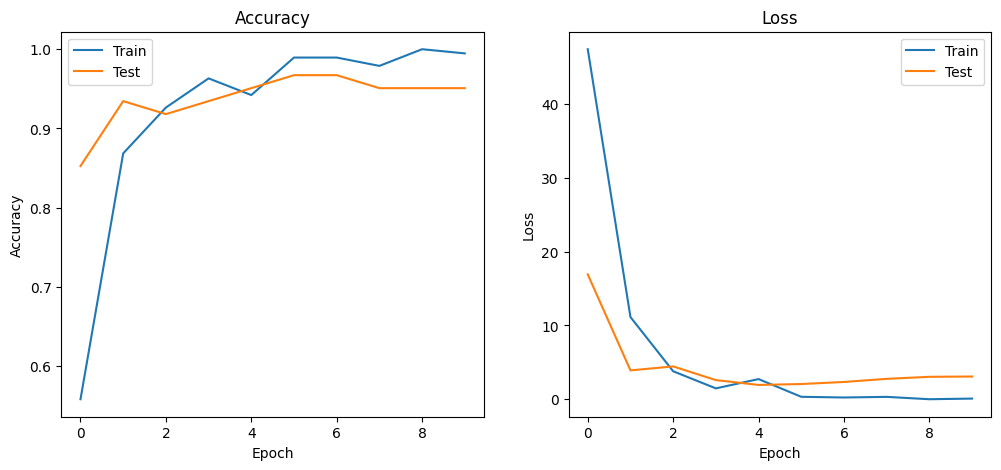

In [54]:
plot_training_curves(history)

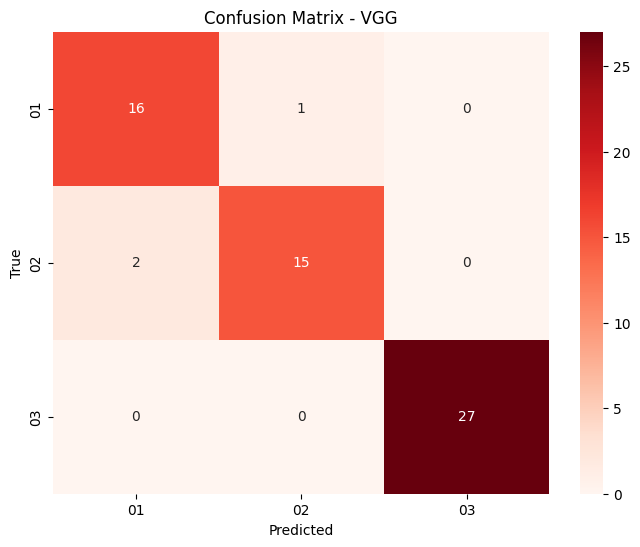

In [55]:
conf_mat(y_test_encoded, y_pred_vgg)

# Summarizing

> Summery the performances of all models

In [56]:
acc = accuracy_score(y_test_encoded, y_pred_vgg)
prec = precision_score(y_test_encoded, y_pred_vgg, average='macro')
rec = recall_score(y_test_encoded, y_pred_vgg, average='macro')
f1 = f1_score(y_test_encoded, y_pred_vgg, average='macro')

vgg_results = pd.DataFrame([{
    'Model': 'VGG',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1-score': round(f1, 4)
}])

print("\nSummary of VGG Model Performance:\n")
print(vgg_results.to_string(index=False))


Summary of VGG Model Performance:

Model  Accuracy  Precision  Recall  F1-score
  VGG    0.9508     0.9421  0.9412    0.9411


### Predicting

> Perform prediction on the VGG model

In [57]:
def pred(predicted_labels, predicted_folder_names, name):
  print("--"*10, name, "--"*10)
  mistakes = 0
  for i, (image, true_folder) in enumerate(test_images):
      if predicted_folder_names[i] != true_folder:
          mistakes += 1
          print(f"Image: {os.path.basename(image.filename):<20} True Folder: {true_folder:<10} Predicted Folder: {predicted_folder_names[i]}")
  print(f"\nMistakes: {mistakes} out of {len(test_images)}")
  print(f"Accuracy: {(len(test_images) - mistakes) / len(test_images):.2f}")

In [58]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
predicted_folder_names = label_encoder.inverse_transform(predicted_labels)

pred(predicted_labels, predicted_folder_names , "VGG")

2/2 ━━━━━━━━━━━━━━━━━━━━ 40s 19s/step
-------------------- VGG --------------------
Image: 07.jpeg              True Folder: 02         Predicted Folder: 01
Image: 064.jpeg             True Folder: 02         Predicted Folder: 01
Image: 06.jpeg              True Folder: 01         Predicted Folder: 02

Mistakes: 3 out of 61
Accuracy: 0.95


### Saving

> Save all the models to Google Drive

In [59]:
model_folder_id = '1x4b4X-meKrRaD5CrXzjUsabrH0OxKvql'
model_filename = 'vgg19.keras'
model.save(model_filename)

gfile = drive.CreateFile({'title': model_filename, 'parents': [{'id': model_folder_id}]})
gfile.SetContentFile(model_filename)
gfile.Upload()

print(f"✅ {model_filename} uploaded to Google Drive")

✅ vgg19.keras uploaded to Google Drive


### Loading

> Load the VGG from Google Drive and Perform prediction

In [60]:
file_list = drive.ListFile({'q': f"'{model_folder_id}' in parents and trashed=false"}).GetList()
model_filename = "vgg19.keras"

for file in file_list:
    if file['title'] == model_filename:
        file.GetContentFile(model_filename)
        print(f"Downloaded {model_filename} successfully!")
        break
else:
    raise ValueError(f"File '{model_filename}' was not found in folder ID {model_folder_id}.")

loaded_model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully!")

Downloaded vgg19.keras successfully!
Model loaded successfully!


In [61]:
test_loss, test_acc = loaded_model.evaluate(X_test, y_test_encoded)
predictions = loaded_model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
predicted_folder_names = label_encoder.inverse_transform(predicted_labels)
pred(predicted_labels, predicted_folder_names , "VGG")

2/2 ━━━━━━━━━━━━━━━━━━━━ 41s 19s/step - accuracy: 0.9464 - loss: 2.2370
2/2 ━━━━━━━━━━━━━━━━━━━━ 52s 20s/step
-------------------- VGG --------------------
Image: 07.jpeg              True Folder: 02         Predicted Folder: 01
Image: 064.jpeg             True Folder: 02         Predicted Folder: 01
Image: 06.jpeg              True Folder: 01         Predicted Folder: 02

Mistakes: 3 out of 61
Accuracy: 0.95
